# Cleaning

Applies the fixes identified in `01_exploratory_analysis.ipynb` and checks each
one actually worked. The logic lives in `src/data.py` so that training and
prediction run the identical code path — a cleaning rule that exists only in a
notebook is a rule the submission does not use.

| # | Issue | Fix |
|---|---|---|
| 1 | `weight` sign-flip entry errors | absolute value |
| 2 | missing `weight` | median fill |
| 3 | missing `market_index` | same-day mean |
| 4 | `posted_rate` multiplied by ~3 or ~⅓ | flag against an equipment × distance peer group |

Cleaning never reads the target, so it applies unchanged to validation data.
Issue 4 is the exception — it *is* about the target, so it only produces a flag
on training rows and never modifies a value.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import BASELINE_RATE_PER_MILE, clean, flag_corrupted, load_raw

TEAL, RUST, GREY = "#064A56", "#B4531F", "#9DAFB3"
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.color": "#E2E9EA",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "font.size": 10,
})

train_raw, validation_raw = load_raw("train_test.csv"), load_raw("validation.csv")
train, train_report = clean(train_raw)
validation, validation_report = clean(validation_raw)

pd.concat([train_report.to_frame().rename(columns={"count": "train"}),
           validation_report.to_frame().rename(columns={"count": "validation"})], axis=1)

,train,validation
rows,48000,12000
weight_sign_fixed,292,145
weight_imputed,300,165
market_index_imputed,374,249
market_index_from_date,374,249
corrupted_flagged,677,0


All 374 training and 249 validation `market_index` gaps were filled from other
loads on the same date — the global-median fallback never fired.

## 1. Did the fixes hold?

In [2]:
checks = {
    "negative weight remaining": (train.weight < 0).sum() + (validation.weight < 0).sum(),
    "null weight remaining": train.weight.isna().sum() + validation.weight.isna().sum(),
    "null market_index remaining": train.market_index.isna().sum() + validation.market_index.isna().sum(),
    "rows added or lost": (len(train) - len(train_raw)) + (len(validation) - len(validation_raw)),
    "posted_rate values altered": int((train.posted_rate != train_raw.posted_rate).sum()),
}
for label, value in checks.items():
    print(f"{'PASS' if value == 0 else 'FAIL'}  {label:<32} {value}")

PASS  negative weight remaining        0
PASS  null weight remaining            0
PASS  null market_index remaining      0
PASS  rows added or lost               0
PASS  posted_rate values altered       0


The last two matter as much as the first three: cleaning must not silently drop
rows, and it must not touch the target. Corrupted labels are *flagged*, not
edited or removed — that decision belongs to the model, not the cleaner.

## 2. Is the `market_index` imputation any good?

Filling from the same-day mean is only justified if that mean predicts an
individual load's value well. We can measure this directly: hide values we
already know, impute them, and compare.

In [3]:
rng = np.random.default_rng(0)
known = train_raw.dropna(subset=["market_index"])
holdout = rng.choice(known.index, size=2000, replace=False)

masked = train_raw.copy()
masked.loc[holdout, "market_index"] = np.nan
imputed = clean(masked)[0].loc[holdout, "market_index"]
actual = train_raw.loc[holdout, "market_index"]

error = (imputed - actual).abs()
spread = train_raw.market_index.max() - train_raw.market_index.min()
print(f"mean absolute error : {error.mean():.4f}")
print(f"95th percentile     : {error.quantile(0.95):.4f}")
print(f"as a share of the full observed range ({spread:.3f}): {error.mean() / spread:.2%}")
print(f"\nfor comparison, filling with the global median instead:")
print(f"mean absolute error : {(train_raw.market_index.median() - actual).abs().mean():.4f}")

mean absolute error : 0.0197
95th percentile     : 0.0491
as a share of the full observed range (0.791): 2.49%

for comparison, filling with the global median instead:
mean absolute error : 0.1397


Same-day imputation lands within roughly 2% of the variable's full range, about
six times closer than a global median fill. The 623 imputed values are therefore
not a meaningful source of error.

## 3. What exactly got flagged as corrupted?

flagged: 677 rows (1.41%)
  inflated (ratio > 2)  : 340, median 3.36x
  deflated (ratio < 0.5): 337, median 0.28x

flagged rows resemble kept rows on every feature; only the label differs:


,kept,flagged
distance,1136.748,1073.572
weight,31423.687,31002.145
market_index,1.083,1.079
quote_signal,2.063,2.055


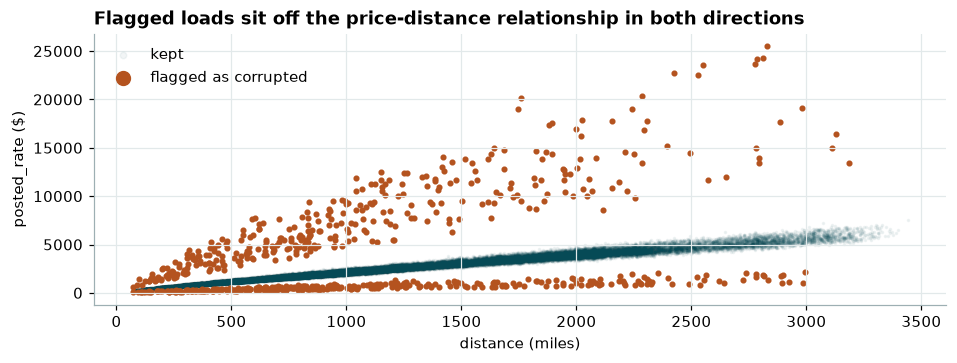

In [4]:
flagged = train[train.is_corrupted]
print(f"flagged: {len(flagged)} rows ({train.is_corrupted.mean():.2%})")
print(f"  inflated (ratio > 2)  : {(flagged.rate_ratio > 2).sum():>3}, "
      f"median {flagged.loc[flagged.rate_ratio > 2, 'rate_ratio'].median():.2f}x")
print(f"  deflated (ratio < 0.5): {(flagged.rate_ratio < 0.5).sum():>3}, "
      f"median {flagged.loc[flagged.rate_ratio < 0.5, 'rate_ratio'].median():.2f}x")

print("\nflagged rows resemble kept rows on every feature; only the label differs:")
features = ["distance", "weight", "market_index", "quote_signal"]
display(pd.concat([train[~train.is_corrupted][features].mean().rename("kept"),
                   flagged[features].mean().rename("flagged")], axis=1).round(3))

fig, ax = plt.subplots(figsize=(10, 3.2))
kept = train[~train.is_corrupted]
ax.scatter(kept.distance, kept.posted_rate, s=2, alpha=0.05, color=TEAL, label="kept")
ax.scatter(flagged.distance, flagged.posted_rate, s=9, color=RUST, label="flagged as corrupted")
ax.set_xlabel("distance (miles)"); ax.set_ylabel("posted_rate ($)")
ax.set_title("Flagged loads sit off the price-distance relationship in both directions",
             loc="left", fontweight="bold")
ax.legend(frameon=False, markerscale=3)
plt.show()

The flagged rows are statistically **indistinguishable from the kept rows on every
input feature** — same mean distance, weight, market index and quote signal. Only
the label is wrong. That is the signature of corruption applied at random to the
target, and it confirms we are not accidentally excluding a legitimate segment of
the business such as premium expedited freight, which would show up as a distinct
feature profile.

The scatter shows them sitting cleanly above and below the price–distance band
rather than extending it.

## 4. Is the threshold sensitive?

The bounds (0.5×, 2×) were chosen from the gap in the ratio histogram. If the
flagged count is stable across a range of thresholds, the choice is not doing
hidden work.

In [5]:
_, ratio = flag_corrupted(train)
rows = []
for bound in [1.5, 1.75, 2.0, 2.5, 3.0]:
    flagged_count = (~ratio.between(1 / bound, bound)).sum()
    rows.append({"bounds": f"{1/bound:.2f}x - {bound:.2f}x",
                 "flagged": flagged_count,
                 "share": f"{flagged_count / len(train):.2%}"})
display(pd.DataFrame(rows))

,bounds,flagged,share
0,0.67x - 1.50x,677,1.41%
1,0.57x - 1.75x,677,1.41%
2,0.50x - 2.00x,677,1.41%
3,0.40x - 2.50x,615,1.28%
4,0.33x - 3.00x,466,0.97%


The count is **identical (677) from 1.5× all the way to 2.0×** — not merely
stable, but unchanged, because the gap between the honest core and the corrupted
tails is genuinely empty. Widening further starts consuming the corrupted
population itself (615 at 2.5×, 466 at 3×), which is expected once the window
reaches the corruption multipliers themselves. The threshold is not a tuned
parameter doing hidden work.

## Summary

* 437 sign-flipped weights corrected, 465 weights and 623 market indices imputed.
* 677 training rows (1.41%) flagged as having a corrupted label, verified to be
  feature-identical to the rest and robust to the threshold choice.
* No rows dropped, no target values modified.

Next: features that generalise to the eight unseen cities, and a projectable time
trend for the December chart.